<a href="https://colab.research.google.com/github/ClaretWheel1481/Artificial-Intelligence/blob/main/DeepLearning/Cifar10%E5%88%86%E7%B1%BB%E9%A2%84%E6%B5%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
# # %autosave 0
# os.removedirs('./drive/MyDrive/dataset/test/.ipynb_checkpoints')
# os.removedirs('./drive/MyDrive/dataset/train/.ipynb_checkpoints')
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [ ]:
data_tf = {
    'train': transforms.Compose([
        transforms.RandomAffine(degrees=50, translate=(0.2,0.2), scale=(0.8,1.2)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485,0.456,0.406),std=(0.229,0.224,0.225))
    ]),
    'test' : transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485,0.456,0.406),std=(0.229,0.224,0.225))
    ])
}

In [ ]:
train_datasets = datasets.ImageFolder(root=r'./drive/MyDrive/dataset/train',transform=data_tf['train'])
test_datasets = datasets.ImageFolder(root=r'./drive/MyDrive/dataset/test',transform=data_tf['test'])

In [ ]:
train_loader = DataLoader(train_datasets, batch_size=64, shuffle=True)
test_loader = DataLoader(test_datasets, batch_size=64, shuffle=True)

In [ ]:
class_dict = train_datasets.class_to_idx
print(class_dict)
class_names=dict((val,key) for key,val in class_dict.items())
class_names

{'bus': 0, 'dinosaurs': 1, 'elephants': 2, 'flowers': 3, 'horse': 4}


{0: 'bus', 1: 'dinosaurs', 2: 'elephants', 3: 'flowers', 4: 'horse'}

In [ ]:
imgs,labels = next(iter(train_loader))
imgs = imgs.numpy()
labels = labels.numpy()

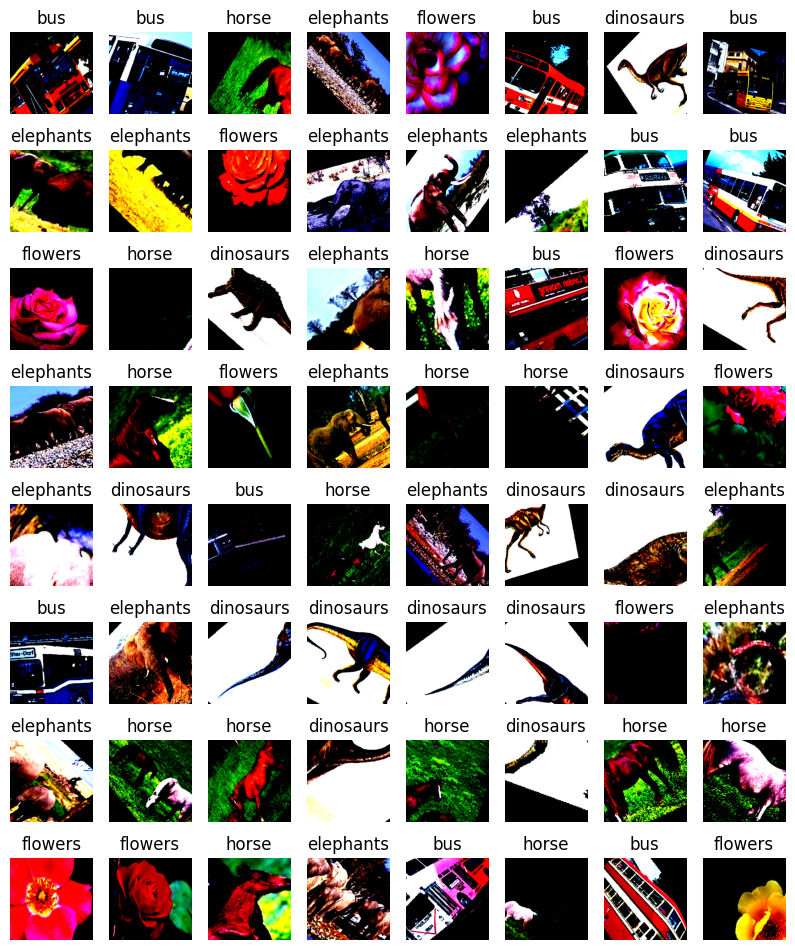

In [ ]:
plt.figure(figsize=(10,12),dpi=100)
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(imgs[i].transpose(1,2,0))
    plt.axis('off')
    plt.title(class_names[labels[i]])

In [ ]:
resnet18 = models.resnet18(pretrained=True)
resnet18

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
fc_in = resnet18.fc.in_features

resnet18.fc = torch.nn.Linear(in_features=fc_in,out_features=5)
resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(resnet18.parameters(),lr=0.000,weight_decay=0.0001)

In [ ]:
for epoch in range(20):
    loop = tqdm(enumerate(train_loader),total = len(train_loader))

    losses=[]
    accuracy = []

    for step, data in loop:
        inputs,labels = data
        inputs = inputs.cuda()
        labels = labels.cuda()
        resnet18 = resnet18.cuda()

        # 前向传播
        outs = resnet18(inputs)
        loss = criterion(outs,labels)
        losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计训练过程准确率
        pred = torch.argmax(outs,1)
        num_correct = (pred==labels).sum()
        accuracy.append(num_correct.item() / inputs.size(0))

        loop.set_description(f'Epoch:{epoch+1}')
        loop.set_postfix(loss=np.mean(losses))

Epoch:20: 100%|██████████| 7/7 [00:03<00:00,  1.81it/s, loss=0.0352]


In [ ]:
resnet18.eval()
for data in test_loader:
    inputs,labels = data
    inputs = inputs.cuda()
    labels = labels.cuda()
    outs = resnet18(inputs)
    pred = torch.argmax(outs,1)
    correct = (pred == labels).sum()

print(f'测试集中的准确率为：{correct / len(test_datasets):.4f}')

测试集中的准确率为：0.3600


In [ ]:
imagelist = [r'./drive/MyDrive/dataset/test/flowers/'+ name for name in os.listdir(r'./drive/MyDrive/dataset/test/flowers')] + \
[r'./drive/MyDrive/dataset/test/bus/'+ name for name in os.listdir(r'./drive/MyDrive/dataset/test/bus')] + \
[r'./drive/MyDrive/dataset/test/dinosaurs/'+ name for name in os.listdir(r'./drive/MyDrive/dataset/test/dinosaurs')] + \
[r'./drive/MyDrive/dataset/test/elephants/'+ name for name in os.listdir(r'./drive/MyDrive/dataset/test/elephants')] + \
[r'./drive/MyDrive/dataset/test/horse/'+ name for name in os.listdir(r'./drive/MyDrive/dataset/test/horse')]

In [ ]:
from random import shuffle
shuffle(imagelist)

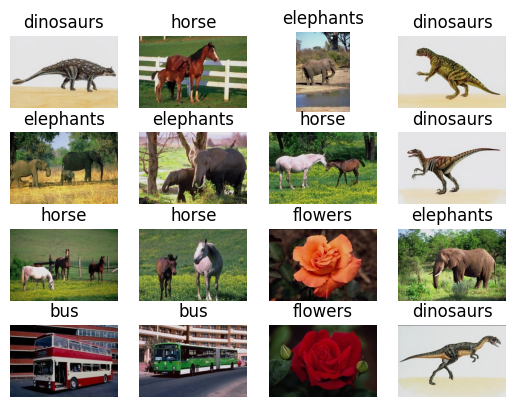

In [ ]:
from PIL import Image
for i in range(16):
  plt.subplot(4,4,i+1)
  img = Image.open(imagelist[i])
  plt.imshow(img)
  plt.axis('off')

  img = data_tf['test'](img).unsqueeze(0)
  img = img.cuda()
  outs = resnet18(img)
  pred = torch.argmax(outs,1)[0]
  plt.title(class_names[pred.item()])